In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

df = pd.read_parquet("data/processed/lineups_featured.parquet")
print("Shape:", df.shape)
print("\nKey columns:")
print(df[["GROUP_NAME", "SEASON", "NET_RATING", "OFF_RATING", "DEF_RATING", "MIN", "SYNERGY_SCORE"]].head())

Shape: (5167, 105)

Key columns:
                                          GROUP_NAME   SEASON  NET_RATING  \
0  P. Millsap - W. Barton - G. Harris - N. Jokic ...  2019-20         7.7   
1  K. Love - T. Thompson - C. Osman - C. Sexton -...  2019-20        -8.6   
2  B. Bogdanovic - R. Gobert - J. Ingles - R. O'N...  2019-20        13.7   
3  L. Aldridge - D. DeRozan - T. Lyles - D. Murra...  2019-20         0.0   
4  G. Temple - S. Dinwiddie - J. Harris - T. Prin...  2019-20        -0.1   

   OFF_RATING  DEF_RATING    MIN  SYNERGY_SCORE  
0       110.9       103.2  735.0          1.750  
1       107.1       115.7  679.0          0.400  
2       116.7       102.9  570.0          8.200  
3       110.3       110.3  505.0          3.680  
4       107.8       108.0  491.0         -0.575  


In [3]:
print("NET_RATING stats:")
print(df["NET_RATING"].describe())

print("\nSYNERGY_SCORE stats:")
print(df["SYNERGY_SCORE"].describe())

print("\nLineups per season:")
print(df["SEASON"].value_counts().sort_index())

NET_RATING stats:
count    5167.000000
mean        2.082814
std        21.284149
min       -75.700000
25%       -11.300000
50%         2.400000
75%        15.600000
max        79.800000
Name: NET_RATING, dtype: float64

SYNERGY_SCORE stats:
count    5167.000000
mean        2.035376
std        20.397907
min       -77.740000
25%       -10.440000
50%         2.380000
75%        14.680000
max        79.720000
Name: SYNERGY_SCORE, dtype: float64

Lineups per season:
SEASON
2019-20     958
2020-21     972
2021-22    1086
2022-23    1029
2023-24    1122
Name: count, dtype: int64


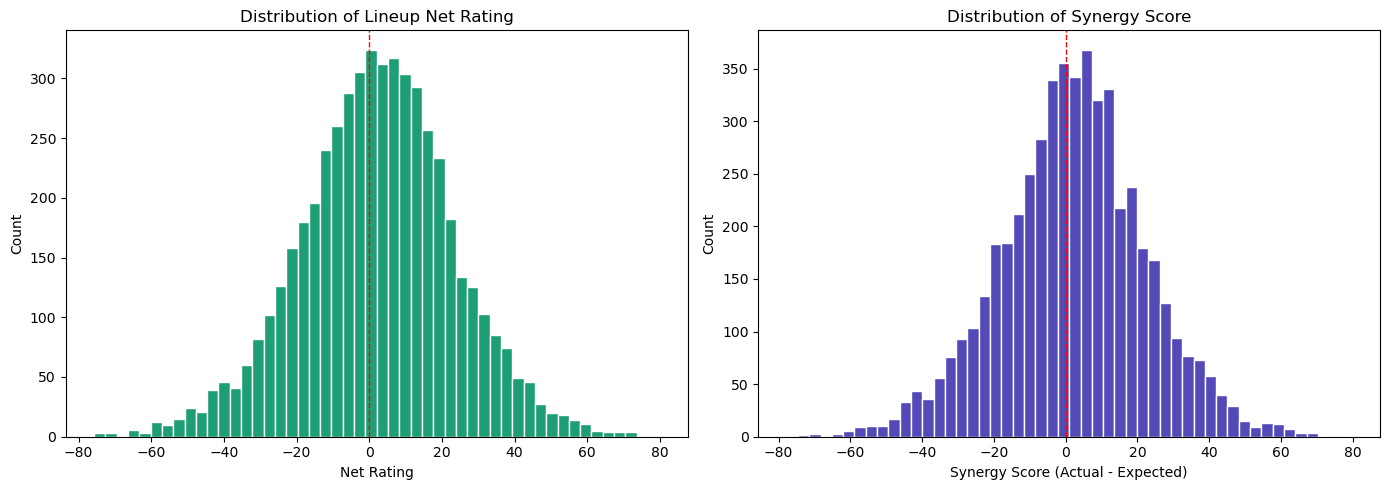

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["NET_RATING"], bins=50, color="#1d9e75", edgecolor="white")
axes[0].set_title("Distribution of Lineup Net Rating")
axes[0].set_xlabel("Net Rating")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

axes[1].hist(df["SYNERGY_SCORE"], bins=50, color="#534ab7", edgecolor="white")
axes[1].set_title("Distribution of Synergy Score")
axes[1].set_xlabel("Synergy Score (Actual - Expected)")
axes[1].set_ylabel("Count")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("notebooks/net_rating_distribution.png", dpi=150)
plt.show()

In [7]:
cols = ["GROUP_NAME", "SEASON", "MIN", "NET_RATING", "SYNERGY_SCORE"]

print("TOP 10 LINEUPS BY NET RATING:")
print(df.nlargest(10, "NET_RATING")[cols].to_string(index=False))

print("\nBOTTOM 10 LINEUPS BY NET RATING:")
print(df.nsmallest(10, "NET_RATING")[cols].to_string(index=False))

TOP 10 LINEUPS BY NET RATING:
                                                         GROUP_NAME  SEASON  MIN  NET_RATING  SYNERGY_SCORE
           N. Batum - K. Leonard - M. Plumlee - T. Mann - B. Hyland 2022-23 20.0        79.8          79.72
G. Hill - J. Holiday - G. Antetokounmpo - P. Connaughton - G. Allen 2021-22 42.0        72.4          68.62
      Z. LaVine - L. Markkanen - D. Theis - T. Brown Jr. - C. White 2020-21 23.0        72.3          73.20
        C. Anthony - E. Kanter - D. Lillard - A. Simons - N. Little 2020-21 20.0        71.0          73.55
R. Hollis-Jefferson - P. Siakam - C. Boucher - T. Davis - M. Thomas 2019-20 20.0        70.7          64.54
     A. Davis - D. Schroder - D. Russell - R. Hachimura - A. Reaves 2022-23 20.0        70.1          67.60
            D. Green - T. Harris - S. Curry - J. Embiid - S. Milton 2020-21 22.0        69.8          63.10
        T. Gibson - A. Burks - O. Toppin - I. Quickley - M. McBride 2021-22 25.0        69.5          63.0

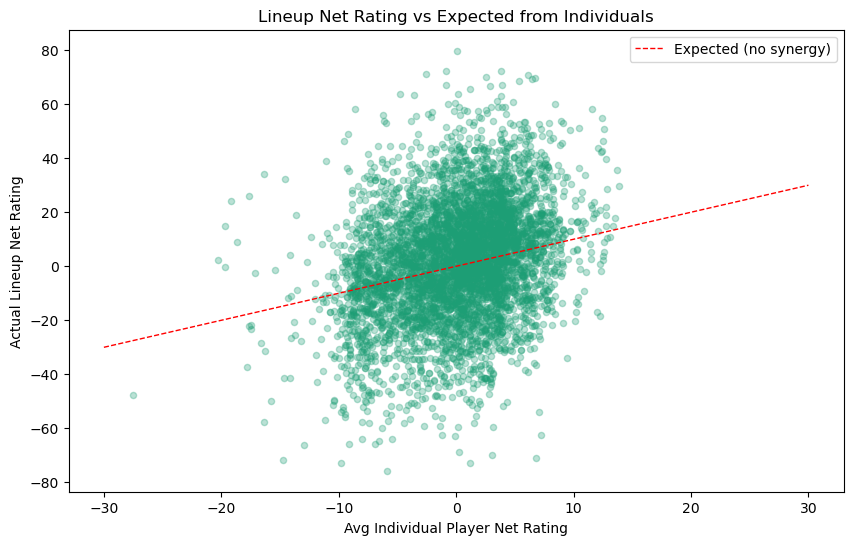

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df["AVG_PLAYER_NET_RATING"], df["NET_RATING"],
            alpha=0.3, s=20, color="#1d9e75")
plt.plot([-30, 30], [-30, 30], "r--", linewidth=1, label="Expected (no synergy)")
plt.xlabel("Avg Individual Player Net Rating")
plt.ylabel("Actual Lineup Net Rating")
plt.title("Lineup Net Rating vs Expected from Individuals")
plt.legend()
plt.savefig("notebooks/synergy_scatter.png", dpi=150)
plt.show()

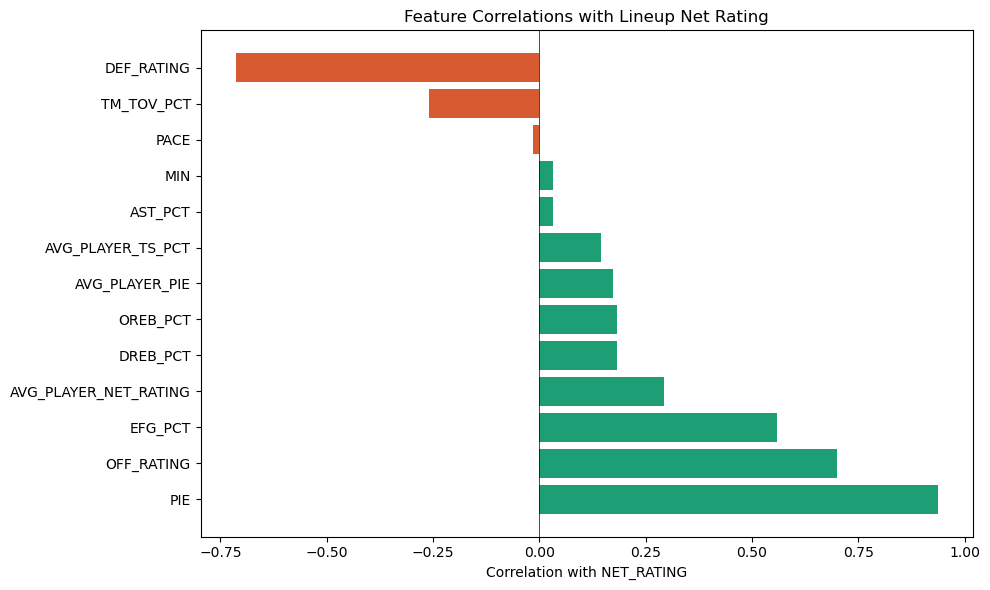

PIE                      0.937033
OFF_RATING               0.700128
EFG_PCT                  0.560178
AVG_PLAYER_NET_RATING    0.293685
DREB_PCT                 0.182220
OREB_PCT                 0.181673
AVG_PLAYER_PIE           0.172921
AVG_PLAYER_TS_PCT        0.144943
AST_PCT                  0.033092
MIN                      0.031728
PACE                    -0.014012
TM_TOV_PCT              -0.258205
DEF_RATING              -0.713898
Name: NET_RATING, dtype: float64


In [11]:
feature_cols = [
    "AVG_PLAYER_NET_RATING", "AVG_PLAYER_TS_PCT", "AVG_PLAYER_PIE",
    "OFF_RATING", "DEF_RATING", "MIN", "PACE", "PIE",
    "AST_PCT", "OREB_PCT", "DREB_PCT", "TM_TOV_PCT", "EFG_PCT"
]

corr = df[feature_cols + ["NET_RATING"]].corr()["NET_RATING"].drop("NET_RATING").sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ["#1d9e75" if x > 0 else "#d85a30" for x in corr.values]
plt.barh(corr.index, corr.values, color=colors)
plt.xlabel("Correlation with NET_RATING")
plt.title("Feature Correlations with Lineup Net Rating")
plt.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("notebooks/correlations.png", dpi=150)
plt.show()

print(corr)